In [1]:
# If any library is missing, run:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import os

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
    PowerTransformer
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
import pandas as pd

DATA_PATH = "C:/Users/Prasun Das/Downloads/career_ai_dataset_1000_11percent_missing.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (1000, 11)


,Education,Experience_Years,Projects_Count,Certification,Python,JavaScript,SQL,Machine_Learning,Java,HTML_CSS,Career_Role
0,B.Tech,5.0,3.0,NaN,1.0,NaN,0.0,NaN,1.0,0.0,Software Engineer
1,B.Tech,0.0,2.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,Machine Learning Engineer
2,MCA,1.0,4.0,NaN,1.0,0.0,1.0,1.0,0.0,0.0,Data Analyst
3,B.Tech,NaN,3.0,Coursera,1.0,1.0,0.0,0.0,0.0,0.0,Backend Developer
4,B.Tech,NaN,8.0,NaN,1.0,NaN,1.0,0.0,1.0,NaN,Full Stack Developer


In [5]:
print("Dataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print(column)

Dataset dimensions:
Rows: 1000
Columns: 11

Column names:
Education
Experience_Years
Projects_Count
Certification
Python
JavaScript
SQL
Machine_Learning
Java
HTML_CSS
Career_Role


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Education         896 non-null    object 
 1   Experience_Years  881 non-null    float64
 2   Projects_Count    872 non-null    float64
 3   Certification     428 non-null    object 
 4   Python            893 non-null    float64
 5   JavaScript        904 non-null    float64
 6   SQL               903 non-null    float64
 7   Machine_Learning  894 non-null    float64
 8   Java              877 non-null    float64
 9   HTML_CSS          894 non-null    float64
 10  Career_Role       1000 non-null   object 
dtypes: float64(8), object(3)
memory usage: 86.1+ KB


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Education         896 non-null    object 
 1   Experience_Years  881 non-null    float64
 2   Projects_Count    872 non-null    float64
 3   Certification     428 non-null    object 
 4   Python            893 non-null    float64
 5   JavaScript        904 non-null    float64
 6   SQL               903 non-null    float64
 7   Machine_Learning  894 non-null    float64
 8   Java              877 non-null    float64
 9   HTML_CSS          894 non-null    float64
 10  Career_Role       1000 non-null   object 
dtypes: float64(8), object(3)
memory usage: 86.1+ KB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Education,896,6,B.Tech,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_Years,881.0,NaN,NaN,NaN,2.505108,2.214679,0.0,1.0,2.0,4.0,8.0
Projects_Count,872.0,NaN,NaN,NaN,2.759174,1.868657,0.0,1.0,2.0,4.0,8.0
Certification,428,5,Coursera,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Python,893.0,NaN,NaN,NaN,0.668533,0.471004,0.0,0.0,1.0,1.0,1.0
JavaScript,904.0,NaN,NaN,NaN,0.528761,0.499448,0.0,0.0,1.0,1.0,1.0
SQL,903.0,NaN,NaN,NaN,0.747508,0.434683,0.0,0.0,1.0,1.0,1.0
Machine_Learning,894.0,NaN,NaN,NaN,0.45302,0.498067,0.0,0.0,0.0,1.0,1.0
Java,877.0,NaN,NaN,NaN,0.359179,0.480034,0.0,0.0,0.0,1.0,1.0
HTML_CSS,894.0,NaN,NaN,NaN,0.457494,0.498469,0.0,0.0,0.0,1.0,1.0


In [9]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Certification,572,57.2
Projects_Count,128,12.8
Java,123,12.3
Experience_Years,119,11.9
Python,107,10.7
HTML_CSS,106,10.6
Machine_Learning,106,10.6
Education,104,10.4
SQL,97,9.7
JavaScript,96,9.6


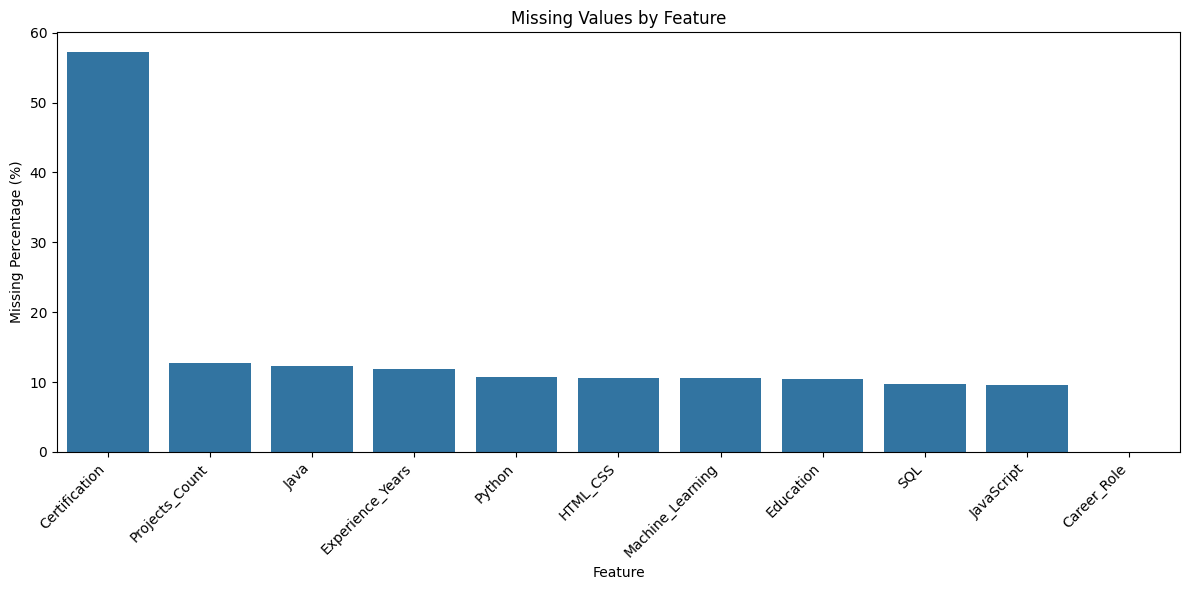

In [10]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing_Percentage"]
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [11]:
duplicate_count = df.duplicated().sum()
print(
    "Number of duplicate rows:",
    duplicate_count
)

Number of duplicate rows: 3


In [12]:
# Dropping duplicate rows 
df = df.drop_duplicates().reset_index(drop=True)
print(
    "Shape after removing duplicates:",
    df.shape
)

Shape after removing duplicates: (997, 11)


In [13]:
career_counts = df["Career_Role"].value_counts()
print(career_counts)

Career_Role
Data Analyst                 161
Backend Developer            149
Full Stack Developer         148
Software Engineer            143
Machine Learning Engineer    138
Data Scientist               133
Frontend Developer           125
Name: count, dtype: int64


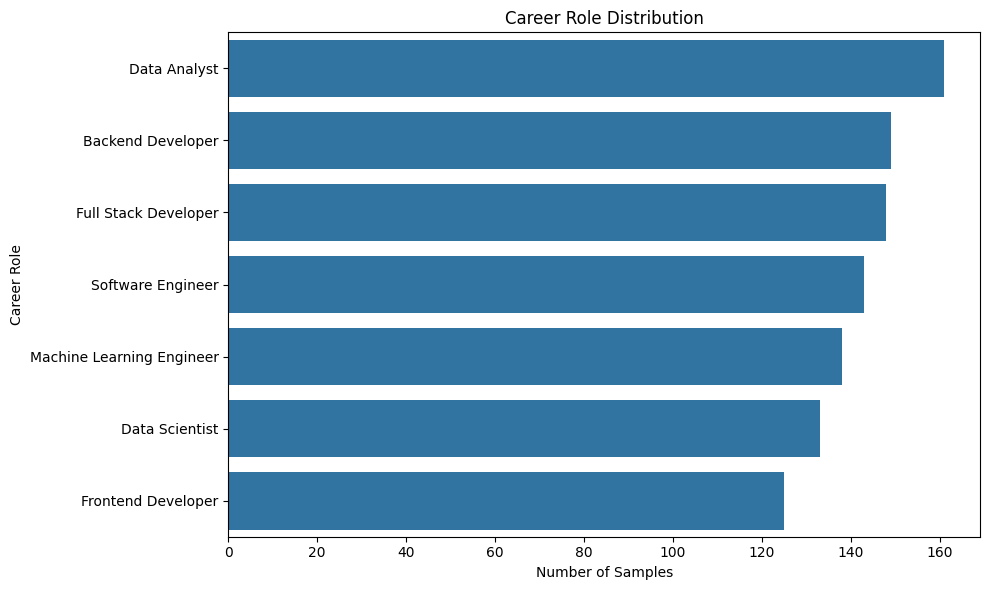

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="Career_Role",
    order=df["Career_Role"].value_counts().index
)
plt.title("Career Role Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Career Role")
plt.tight_layout()
plt.show()

In [15]:
numerical_raw = [
    "Experience_Years",
    "Projects_Count"
]

df[numerical_raw].describe()

,Experience_Years,Projects_Count
count,879.000000,870.000000
mean,2.503982,2.758621
std,2.215018,1.870155
min,0.000000,0.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,4.000000,4.000000
max,8.000000,8.000000


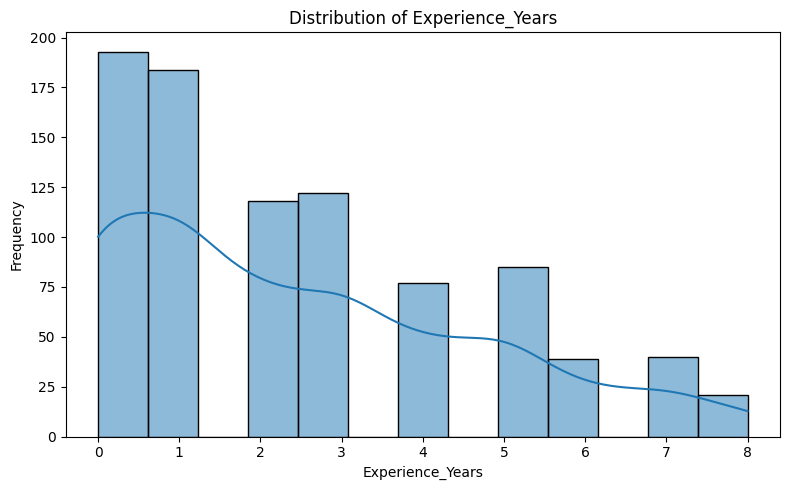

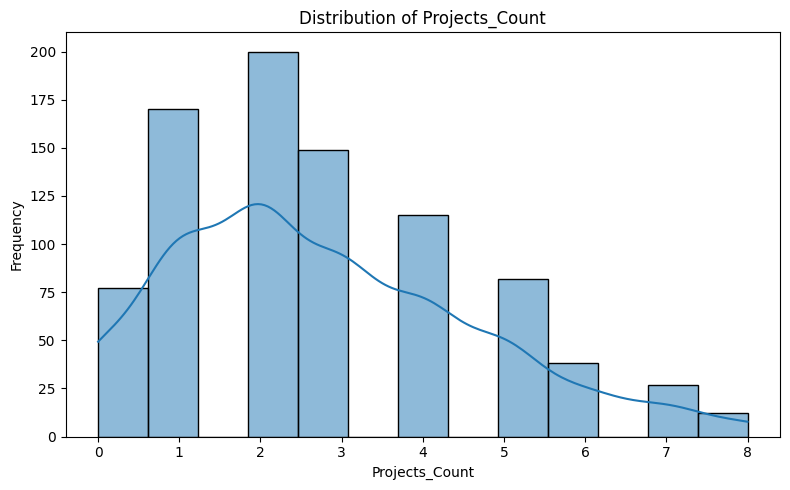

In [16]:
for column in numerical_raw:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

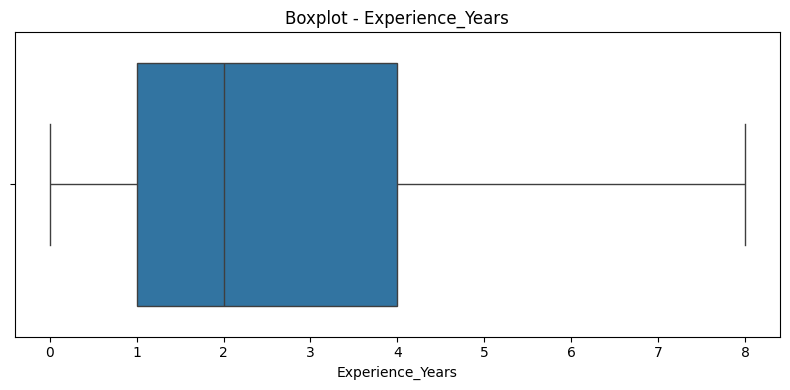

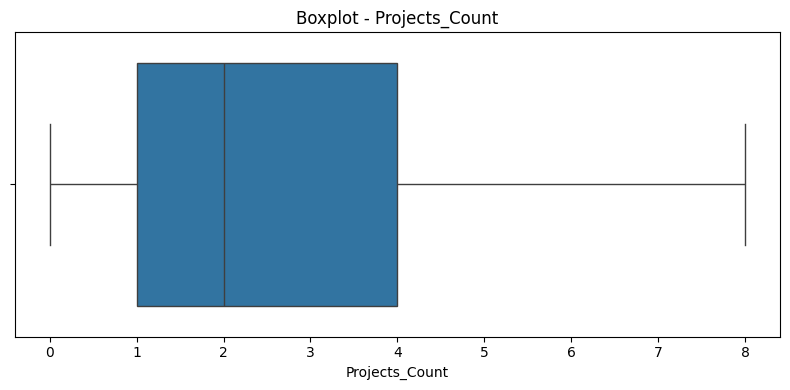

In [17]:
for column in numerical_raw:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Boxplot - {column}"
    )

    plt.xlabel(column)

    plt.tight_layout()

    plt.show()

In [18]:
TARGET_COLUMN = "Career_Role"

X = df.drop(
    columns=[TARGET_COLUMN]
)

y = df[TARGET_COLUMN]

print("Feature shape:", X.shape)

print("Target shape:", y.shape)

Feature shape: (997, 10)
Target shape: (997,)


In [19]:
categorical_features = [
    "Education",
    "Certification"
]


continuous_features = [
    "Experience_Years",
    "Projects_Count"
]


binary_features = [
    "Python",
    "JavaScript",
    "SQL",
    "Machine_Learning",
    "Java",
    "HTML_CSS"
]


print("Categorical features:")
print(categorical_features)

print("\nContinuous features:")
print(continuous_features)

print("\nBinary skill features:")
print(binary_features)

print(
    "\nTotal features:",
    len(categorical_features)
    + len(continuous_features)
    + len(binary_features)
)

Categorical features:
['Education', 'Certification']

Continuous features:
['Experience_Years', 'Projects_Count']

Binary skill features:
['Python', 'JavaScript', 'SQL', 'Machine_Learning', 'Java', 'HTML_CSS']

Total features: 10


In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 797
Testing samples: 200


In [21]:
continuous_pipeline = Pipeline(
    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "transformer",

            PowerTransformer(
                method="yeo-johnson",
                standardize=False
            )
        ),

        (
            "scaler",

            RobustScaler()
        )

    ]
)

In [22]:
binary_pipeline = Pipeline(
    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        )

    ]
)

In [23]:
categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]
)

In [24]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "continuous",

            continuous_pipeline,

            continuous_features
        ),

        (
            "binary",

            binary_pipeline,

            binary_features
        ),

        (
            "categorical",

            categorical_pipeline,

            categorical_features
        )

    ],

    remainder="drop"
)

print(
    "Complete preprocessing pipeline created."
)

Complete preprocessing pipeline created.


In [25]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),


    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ),


    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ),


    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),


    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),


    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        )

}


print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Random Forest
- Extra Trees
- Gradient Boosting
- SVM
- KNN


In [26]:
pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = Pipeline(

        steps=[

            (
                "preprocessing",

                preprocessor
            ),

            (
                "model",

                model
            )

        ]

    )


print(
    "All complete pipelines created."
)

All complete pipelines created.


In [27]:
results = []

trained_pipelines = {}


for model_name, pipeline in pipelines.items():

    print(
        f"\nTraining {model_name}..."
    )

    pipeline.fit(
        X_train,
        y_train
    )


    y_pred = pipeline.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1_Score": f1

    })


    trained_pipelines[
        model_name
    ] = pipeline


results_df = pd.DataFrame(
    results
)


results_df = results_df.sort_values(
    by="F1_Score",
    ascending=False
)


results_df.reset_index(
    drop=True,
    inplace=True
)


results_df


Training Logistic Regression...

Training Random Forest...

Training Extra Trees...

Training Gradient Boosting...

Training SVM...

Training KNN...


,Model,Accuracy,Precision,Recall,F1_Score
0,SVM,0.500,0.501933,0.500,0.489274
1,Logistic Regression,0.495,0.491467,0.495,0.485885
2,Gradient Boosting,0.475,0.474610,0.475,0.468769
3,Random Forest,0.425,0.420268,0.425,0.418894
4,Extra Trees,0.405,0.410723,0.405,0.401808
5,KNN,0.405,0.426442,0.405,0.399193


In [28]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score"
]

for column in metric_columns:

    results_display[column] = (
        results_display[column] * 100
    ).round(2)


results_display

,Model,Accuracy,Precision,Recall,F1_Score
0,SVM,50.0,50.19,50.0,48.93
1,Logistic Regression,49.5,49.15,49.5,48.59
2,Gradient Boosting,47.5,47.46,47.5,46.88
3,Random Forest,42.5,42.03,42.5,41.89
4,Extra Trees,40.5,41.07,40.5,40.18
5,KNN,40.5,42.64,40.5,39.92


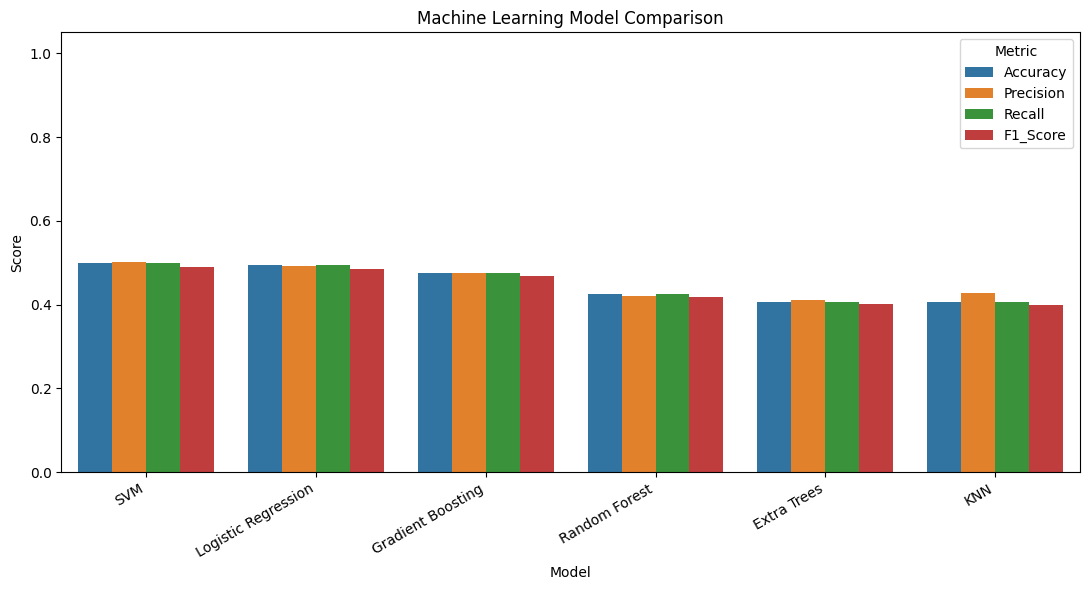

In [29]:
plt.figure(figsize=(11, 6))

plot_data = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Machine Learning Model Comparison"
)

plt.ylabel("Score")

plt.xlabel("Model")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [30]:
best_model_name = (
    results_df.iloc[0]["Model"]
)


best_pipeline = (
    trained_pipelines[
        best_model_name
    ]
)


print(
    "Best model:",
    best_model_name
)


print(
    "Best F1 Score:",
    round(
        results_df.iloc[0]["F1_Score"],
        4
    )
)

Best model: SVM
Best F1 Score: 0.4893


In [31]:
y_pred_best = best_pipeline.predict(
    X_test
)


print(
    classification_report(

        y_test,

        y_pred_best,

        zero_division=0
    )
)

                           precision    recall  f1-score   support

        Backend Developer       0.35      0.37      0.36        30
             Data Analyst       0.56      0.56      0.56        32
           Data Scientist       0.46      0.62      0.52        26
       Frontend Developer       0.62      0.60      0.61        25
     Full Stack Developer       0.53      0.77      0.63        30
Machine Learning Engineer       0.62      0.36      0.45        28
        Software Engineer       0.37      0.24      0.29        29

                 accuracy                           0.50       200
                macro avg       0.50      0.50      0.49       200
             weighted avg       0.50      0.50      0.49       200



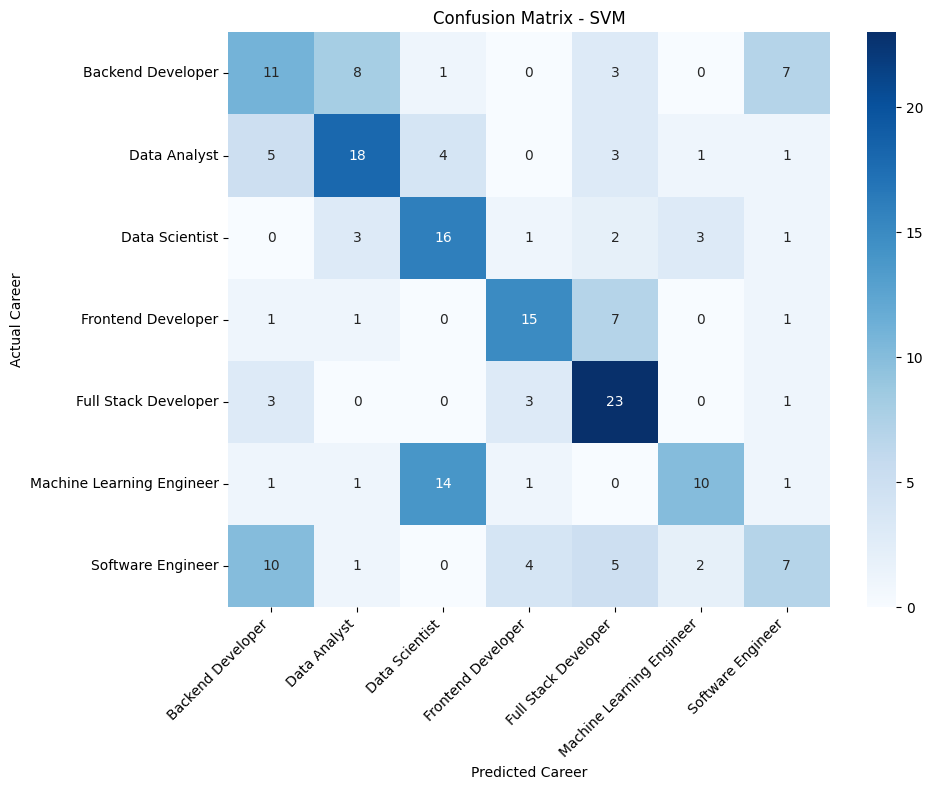

In [32]:
cm = confusion_matrix(

    y_test,

    y_pred_best,

    labels=best_pipeline.classes_

)


plt.figure(
    figsize=(10, 8)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=best_pipeline.classes_,

    yticklabels=best_pipeline.classes_

)


plt.title(
    f"Confusion Matrix - {best_model_name}"
)


plt.xlabel(
    "Predicted Career"
)


plt.ylabel(
    "Actual Career"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()

In [33]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


cv_results = []


for model_name, pipeline in pipelines.items():

    print(
        f"Cross-validating {model_name}..."
    )


    scores = cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring="f1_weighted",

        n_jobs=-1

    )


    cv_results.append({

        "Model": model_name,

        "Mean_F1": scores.mean(),

        "Std_F1": scores.std()

    })


cv_results_df = pd.DataFrame(
    cv_results
)


cv_results_df = cv_results_df.sort_values(
    by="Mean_F1",
    ascending=False
)


cv_results_df

Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating Extra Trees...
Cross-validating Gradient Boosting...
Cross-validating SVM...
Cross-validating KNN...


,Model,Mean_F1,Std_F1
0,Logistic Regression,0.468767,0.029651
4,SVM,0.438824,0.014649
1,Random Forest,0.415225,0.032126
3,Gradient Boosting,0.404704,0.036375
2,Extra Trees,0.393123,0.022849
5,KNN,0.362513,0.013055


In [34]:
sample_user = {

    "Education": "B.Tech",

    "Experience_Years": 1,

    "Projects_Count": 3,

    "Certification": "Coursera",

    "Python": 1,

    "JavaScript": 1,

    "SQL": 1,

    "Machine_Learning": 1,

    "Java": 0,

    "HTML_CSS": 1

}


sample_user_df = pd.DataFrame(
    [sample_user]
)


prediction = best_pipeline.predict(
    sample_user_df
)


print(
    "Predicted Career:"
)

print(
    prediction[0]
)

Predicted Career:
Full Stack Developer


In [35]:
if hasattr(
    best_pipeline,
    "predict_proba"
):

    probabilities = (
        best_pipeline.predict_proba(
            sample_user_df
        )[0]
    )


    classes = (
        best_pipeline.classes_
    )


    probability_df = pd.DataFrame({

        "Career": classes,

        "Probability": probabilities

    })


    probability_df[
        "Probability"
    ] = (

        probability_df[
            "Probability"
        ] * 100

    ).round(2)


    probability_df = (
        probability_df.sort_values(

            by="Probability",

            ascending=False

        )
    )


    probability_df

In [36]:
def predict_career(user_data):

    user_df = pd.DataFrame(
        [user_data]
    )


    prediction = (
        best_pipeline.predict(
            user_df
        )[0]
    )


    result = {

        "career": prediction

    }


    if hasattr(
        best_pipeline,
        "predict_proba"
    ):

        probabilities = (
            best_pipeline.predict_proba(
                user_df
            )[0]
        )


        classes = (
            best_pipeline.classes_
        )


        ranked = sorted(

            zip(
                classes,
                probabilities
            ),

            key=lambda x: x[1],

            reverse=True

        )


        result[
            "recommendations"
        ] = [

            {
                "career": career,

                "probability":
                    round(
                        float(probability) * 100,
                        2
                    )

            }

            for career, probability
            in ranked

        ]


    return result

In [37]:
result = predict_career(
    sample_user
)

result

{'career': 'Full Stack Developer',
 'recommendations': [{'career': 'Full Stack Developer', 'probability': 49.57},
  {'career': 'Data Scientist', 'probability': 14.92},
  {'career': 'Frontend Developer', 'probability': 10.45},
  {'career': 'Backend Developer', 'probability': 9.23},
  {'career': 'Machine Learning Engineer', 'probability': 8.65},
  {'career': 'Data Analyst', 'probability': 4.23},
  {'career': 'Software Engineer', 'probability': 2.95}]}

In [38]:
MODEL_FILE = "career_ai_model.pkl"


with open(
    MODEL_FILE,
    "wb"
) as file:

    pickle.dump(
        best_pipeline,
        file
    )


print(
    "Model successfully saved!"
)


print(
    "File:",
    MODEL_FILE
)


print(
    "Size:",
    round(
        os.path.getsize(
            MODEL_FILE
        ) / 1024,
        2
    ),
    "KB"
)

Model successfully saved!
File: career_ai_model.pkl
Size: 156.85 KB


In [39]:
model_metadata = {

    "model_name":
        best_model_name,

    "target_column":
        TARGET_COLUMN,

    "features":
        list(X.columns),

    "categorical_features":
        categorical_features,

    "continuous_features":
        continuous_features,

    "binary_features":
        binary_features,

    "classes":
        list(
            best_pipeline.classes_
        ),

    "dataset_rows":
        len(df)

}


with open(
    "career_ai_metadata.pkl",
    "wb"
) as file:

    pickle.dump(
        model_metadata,
        file
    )


print(
    "Metadata saved successfully."
)

Metadata saved successfully.


In [40]:
with open(
    "career_ai_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(
        file
    )


loaded_prediction = (
    loaded_model.predict(
        sample_user_df
    )
)


print(
    "Prediction from loaded pickle:"
)

print(
    loaded_prediction[0]
)

Prediction from loaded pickle:
Full Stack Developer


In [41]:
if hasattr(
    loaded_model,
    "predict_proba"
):

    loaded_probabilities = (
        loaded_model.predict_proba(
            sample_user_df
        )[0]
    )


    loaded_probability_df = pd.DataFrame({

        "Career":
            loaded_model.classes_,

        "Probability":
            loaded_probabilities * 100

    })


    loaded_probability_df[
        "Probability"
    ] = loaded_probability_df[
        "Probability"
    ].round(2)


    loaded_probability_df = (
        loaded_probability_df.sort_values(

            by="Probability",

            ascending=False

        )
    )


    loaded_probability_df